In [ ]:
from sklearn.datasets import load_diabetes
import pandas as pd

In [ ]:
dataset = load_diabetes()
dataset

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

In [ ]:
dataset.target_filename

'diabetes_target.csv.gz'

Independent Features = 'age', 'sex',
  'bmi','bp','s1','s2','s3','s4','s5','s6'

Model has to predict a numerical val, that how much the disease will progress by 1 yr

In [ ]:
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [ ]:
#Splitting independent and dependent features
X = df
y = dataset['target']

In [ ]:
#train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)


In [ ]:
#Correlation

df.corr()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
age,1.000000,0.173737,0.185085,0.335428,0.260061,0.219243,-0.075181,0.203841,0.270774,0.301731
sex,0.173737,1.000000,0.088161,0.241010,0.035277,0.142637,-0.379090,0.332115,0.149916,0.208133
bmi,0.185085,0.088161,1.000000,0.395411,0.249777,0.261170,-0.366811,0.413807,0.446157,0.388680
bp,0.335428,0.241010,0.395411,1.000000,0.242464,0.185548,-0.178762,0.257650,0.393480,0.390430
s1,0.260061,0.035277,0.249777,0.242464,1.000000,0.896663,0.051519,0.542207,0.515503,0.325717
s2,0.219243,0.142637,0.261170,0.185548,0.896663,1.000000,-0.196455,0.659817,0.318357,0.290600
s3,-0.075181,-0.379090,-0.366811,-0.178762,0.051519,-0.196455,1.000000,-0.738493,-0.398577,-0.273697
s4,0.203841,0.332115,0.413807,0.257650,0.542207,0.659817,-0.738493,1.000000,0.617859,0.417212
s5,0.270774,0.149916,0.446157,0.393480,0.515503,0.318357,-0.398577,0.617859,1.000000,0.464669
s6,0.301731,0.208133,0.388680,0.390430,0.325717,0.290600,-0.273697,0.417212,0.464669,1.000000


<Axes: >

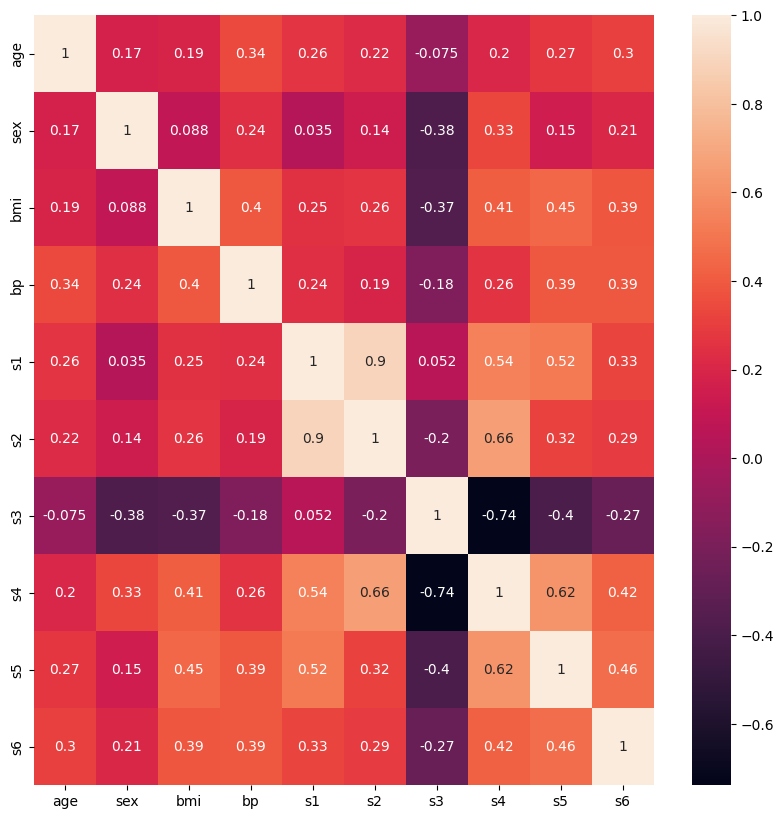

In [ ]:
#Heatmap
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(), annot=True)

In [ ]:
#Fit Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor()
regressor.fit(X_train, y_train)

DecisionTreeRegressor()

In [ ]:
#Performance metrics

from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_score
y_pred = regressor.predict(X_test)

print(r2_score(y_test, y_pred))

-0.14512311041346204


HyperParameter Tuning

In [ ]:
params = {
  'criterion': ['squared_error','friedman_mse','absolute_error',],
  'splitter': ['best','random'],
  'max_depth': [1,2,3,4,5,10,15,20,25],
  'max_features': ['log2','auto','sqrt']
}

In [ ]:
#Remove warnings

import warnings
warnings.filterwarnings('ignore')

In [ ]:
#GridSearchCV

from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(estimator=regressor, param_grid=params, cv=6,scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=6, estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared_error', 'friedman_mse',
                                       'absolute_error'],
                         'max_depth': [1, 2, 3, 4, 5, 10, 15, 20, 25],
                         'max_features': ['log2', 'auto', 'sqrt'],
                         'splitter': ['best', 'random']},
             scoring='neg_mean_squared_error')

In [ ]:
grid_search.best_params_

{'criterion': 'squared_error',
 'max_depth': 3,
 'max_features': 'log2',
 'splitter': 'best'}

In [ ]:
grid_search.best_score_

np.float64(-3971.2995631740396)

In [ ]:
#Performance metrics

from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

y_pred = grid_search.predict(X_test)

print(r2_score(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))

0.35386663447274613
51.53211971419953
4088.5194205817807


In [ ]:
#building the model with the best params chosen thru grid search
selectedmodel = DecisionTreeRegressor(criterion='squared_error', max_depth=3, max_features='log2', splitter='best')
selectedmodel.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=3, max_features='log2')

[Text(0.5, 0.875, 'x[0] <= 0.018\nsquared_error = 5757.456\nsamples = 309\nvalue = 152.738'),
 Text(0.25, 0.625, 'x[6] <= -0.019\nsquared_error = 5418.949\nsamples = 189\nvalue = 137.116'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[4] <= -0.011\nsquared_error = 5875.258\nsamples = 62\nvalue = 179.0'),
 Text(0.0625, 0.125, 'squared_error = 6808.743\nsamples = 24\nvalue = 144.083'),
 Text(0.1875, 0.125, 'squared_error = 4029.366\nsamples = 38\nvalue = 201.053'),
 Text(0.375, 0.375, 'x[4] <= 0.047\nsquared_error = 3921.702\nsamples = 127\nvalue = 116.669'),
 Text(0.3125, 0.125, 'squared_error = 3690.979\nsamples = 116\nvalue = 111.784'),
 Text(0.4375, 0.125, 'squared_error = 3449.603\nsamples = 11\nvalue = 168.182'),
 Text(0.75, 0.625, 'x[6] <= -0.016\nsquared_error = 5300.908\nsamples = 120\nvalue = 177.342'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[8] <= 0.028\nsquared_error = 5139.224\nsamples = 69\nvalue = 201.391'),
 Text(0.5625, 0.125, 'squared_error = 4730.

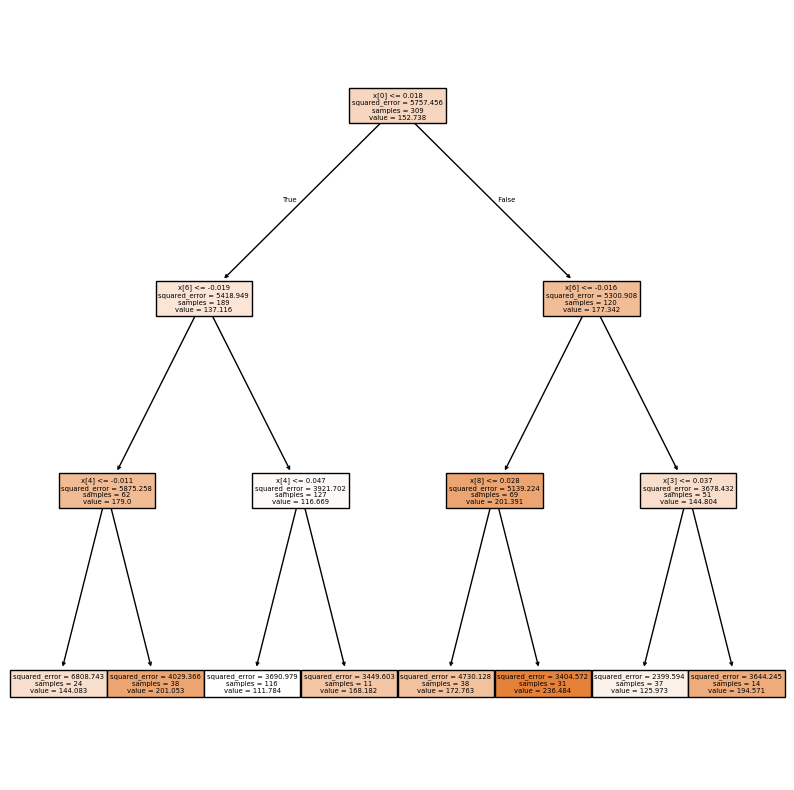

In [ ]:
#Visualize Decision Tree

from sklearn import tree
plt.figure(figsize=(10,10))
tree.plot_tree(selectedmodel, filled=True)